# 02 - Resume Category Classifier (Supervised)
Model A: predicts job domain from resume text. Pipeline: TF-IDF -> Logistic Regression / Linear SVM / Random Forest, best model selected by macro F1.

In [1]:
import sys
sys.path.append('..')
from src.models.classifier import train_and_compare

results, best_name = train_and_compare()

logistic_regression  | acc=0.690  precision=0.671  recall=0.651  f1=0.647


linear_svm           | acc=0.718  precision=0.702  recall=0.680  f1=0.675


random_forest        | acc=0.765  precision=0.799  recall=0.731  f1=0.734

Best model: random_forest



Classification report (best model):
                        precision    recall  f1-score   support

            Accountant       0.70      0.96      0.81        24
              Advocate       0.86      0.75      0.80        24
           Agriculture       1.00      0.46      0.63        13
               Apparel       0.88      0.37      0.52        19
                  Arts       0.62      0.24      0.34        21
            Automobile       1.00      0.29      0.44         7
              Aviation       0.81      0.92      0.86        24
               Banking       0.80      0.70      0.74        23
                   Bpo       1.00      0.50      0.67         4
  Business-Development       0.88      0.92      0.90        24
                  Chef       0.87      0.83      0.85        24
          Construction       0.86      0.86      0.86        22
            Consultant       0.76      0.57      0.65        23
              Designer       0.80      0.95      0.87        21
  

Saved confusion matrix -> /home/claude/smarthire/reports/figures/confusion_matrix_classifier.png



Saved: /home/claude/smarthire/models/classifier.pkl, /home/claude/smarthire/models/tfidf_vectorizer.pkl, /home/claude/smarthire/models/label_encoder.pkl


## Results
Random Forest was selected as the best model by macro F1. See `reports/figures/confusion_matrix_classifier.png` for the full confusion matrix, and the printed classification report above for per-class precision/recall/F1.

**Notes / limitations:**
- Automobile and Bpo have the fewest training examples (~30 and ~18 respectively after the train/test split), which shows up as lower recall for those classes.
- Confusable categories (e.g. Arts vs Digital-Media, Consultant vs Finance) share overlapping vocabulary, which is the main source of misclassification.
- Class weighting (`class_weight='balanced'`) was used across all three models to counter the mild class imbalance.

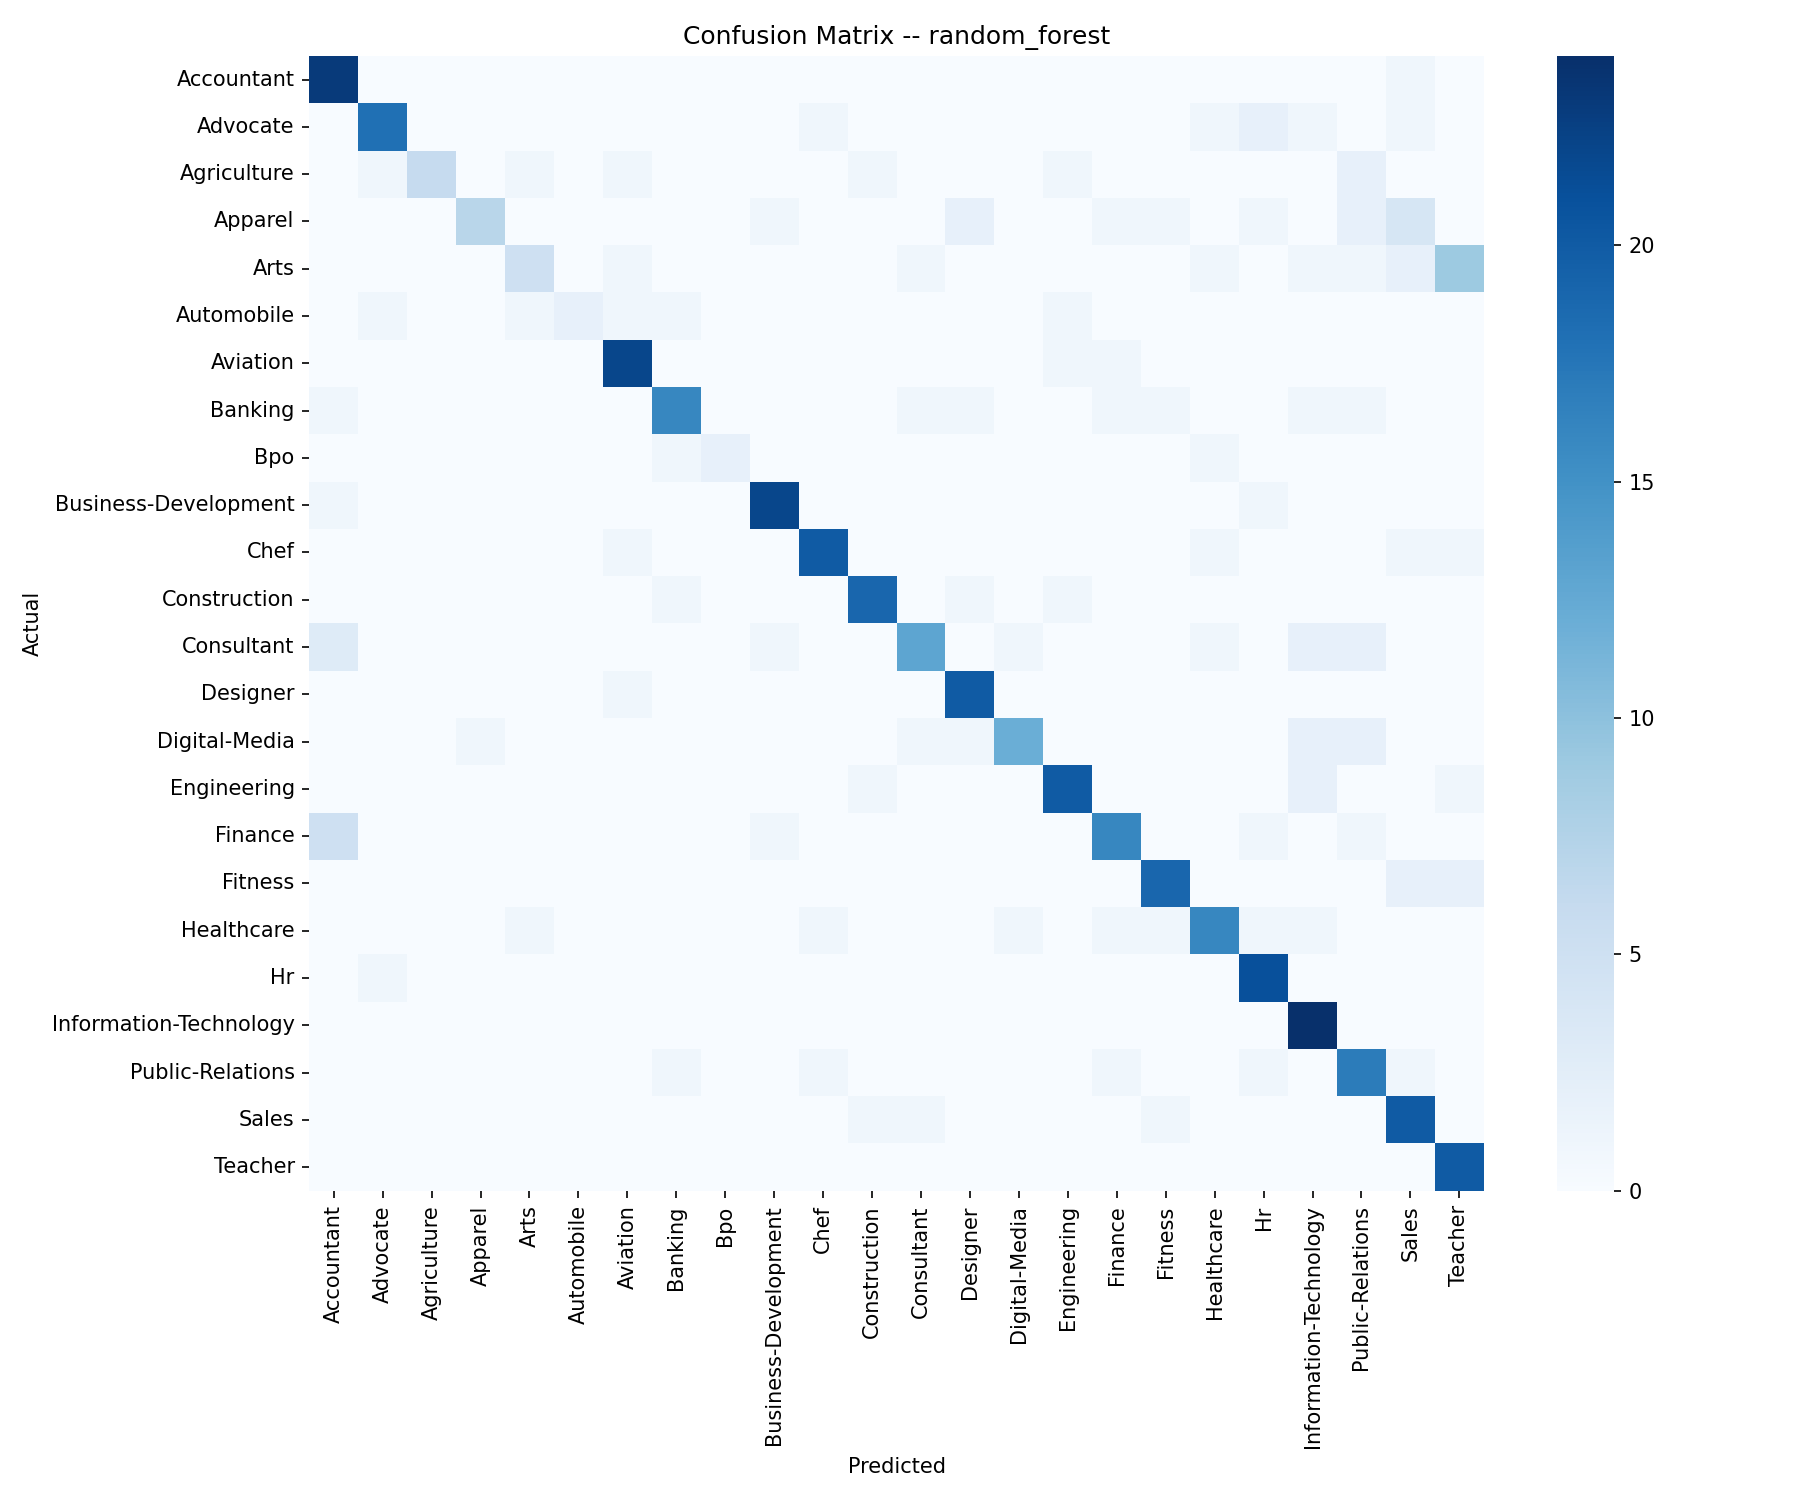

In [2]:
from src.config import FIGURES_DIR
from IPython.display import Image
Image(filename=str(FIGURES_DIR / 'confusion_matrix_classifier.png'))

## Quick sanity check: predict on a new resume snippet

In [3]:
from src.models.classifier import predict_category
from src.data.preprocess import clean_text

sample = """Experienced Python developer skilled in Django, REST APIs, PostgreSQL, and AWS. 
Led a team building microservices for a fintech platform. Strong background in CI/CD and unit testing."""

predict_category(clean_text(sample))

'Construction'